In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

import joblib

In [2]:
df = pd.read_csv("C:\\Users\\Owner\\500L FINAL YEAR PROJECT\\cardio_train.csv", sep=';')
df.head(20)

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
5,8,21914,1,151,67.0,120,80,2,2,0,0,0,0
6,9,22113,1,157,93.0,130,80,3,1,0,0,1,0
7,12,22584,2,178,95.0,130,90,3,3,0,0,1,1
8,13,17668,1,158,71.0,110,70,1,1,0,0,1,0
9,14,19834,1,164,68.0,110,60,1,1,0,0,0,0


In [3]:
# print(df.info())
# print(df.describe())
print(df['cardio'].value_counts()) 

cardio
0    35021
1    34979
Name: count, dtype: int64


In [4]:
# Drop the ID column (it has no predictive value).

df.drop(columns=["id"], inplace=True)

In [5]:
# Convert age from days to years
df["age"] = (df["age"] / 365).astype(int)
df.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,50,2,168,62.0,110,80,1,1,0,0,1,0
1,55,1,156,85.0,140,90,3,1,0,0,1,1
2,51,1,165,64.0,130,70,3,1,0,0,0,1
3,48,2,169,82.0,150,100,1,1,0,0,1,1
4,47,1,156,56.0,100,60,1,1,0,0,0,0


In [6]:
 # Map gender to 0/1 
df['gender'] = df['gender'].map({1: 0, 2: 1})  # 0 = male, 1 = female
df.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,50,1,168,62.0,110,80,1,1,0,0,1,0
1,55,0,156,85.0,140,90,3,1,0,0,1,1
2,51,0,165,64.0,130,70,3,1,0,0,0,1
3,48,1,169,82.0,150,100,1,1,0,0,1,1
4,47,0,156,56.0,100,60,1,1,0,0,0,0


In [7]:
# Create BMI feature ;BMI is very important for heart disease prediction.

df["bmi"] = df["weight"] / ((df["height"] / 100) ** 2)
df.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,bmi
0,50,1,168,62.0,110,80,1,1,0,0,1,0,21.967120
1,55,0,156,85.0,140,90,3,1,0,0,1,1,34.927679
2,51,0,165,64.0,130,70,3,1,0,0,0,1,23.507805
3,48,1,169,82.0,150,100,1,1,0,0,1,1,28.710479
4,47,0,156,56.0,100,60,1,1,0,0,0,0,23.011177


In [8]:
# Remove Outliers ; The dataset contains unrealistic blood pressure values.

df = df[(df["ap_hi"] > 80) & (df["ap_hi"] < 200)]
df = df[(df["ap_lo"] > 50) & (df["ap_lo"] < 130)]

df = df[df["ap_hi"] > df["ap_lo"]]

In [9]:
df.shape

(68382, 13)

In [10]:
X = df.drop(columns=["cardio"])
y = df["cardio"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
# Train Logistic Regression
lr_model = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    C=0.5
)

lr_model.fit(X_train_scaled, y_train)

LogisticRegression(C=0.5, class_weight='balanced', max_iter=2000)

In [14]:
# Evaluate Logistic Regression
y_pred_lr = lr_model.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.7349564963076698

Confusion Matrix:
[[5453 1463]
 [2162 4599]]

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.79      0.75      6916
           1       0.76      0.68      0.72      6761

    accuracy                           0.73     13677
   macro avg       0.74      0.73      0.73     13677
weighted avg       0.74      0.73      0.73     13677



In [15]:
# Cross Validation ; This tells you if the model is stable.

scores = cross_val_score(lr_model, X_train_scaled, y_train, cv=5)

print("Cross Validation Scores:", scores)
print("Average CV Score:", scores.mean())

Cross Validation Scores: [0.7290924  0.72360845 0.72854401 0.72772141 0.71757609]
Average CV Score: 0.7253084727173018


In [19]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=300,      # number of trees
    max_depth=10,          # control tree size
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                       n_estimators=300, n_jobs=-1, random_state=42)

In [20]:
y_pred_rf = rf_model.predict(X_test_scaled)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7397090005118081

Confusion Matrix:
[[5498 1418]
 [2142 4619]]

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.79      0.76      6916
           1       0.77      0.68      0.72      6761

    accuracy                           0.74     13677
   macro avg       0.74      0.74      0.74     13677
weighted avg       0.74      0.74      0.74     13677



In [21]:
xgb_model = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train_scaled, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=None,
              num_parallel_tree=None, ...)

In [22]:
y_pred_xgb = xgb_model.predict(X_test_scaled)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.7386122687723916

Confusion Matrix:
[[5396 1520]
 [2055 4706]]

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.78      0.75      6916
           1       0.76      0.70      0.72      6761

    accuracy                           0.74     13677
   macro avg       0.74      0.74      0.74     13677
weighted avg       0.74      0.74      0.74     13677



In [23]:
models = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

for name, model in models.items():
    pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, pred)
    print(f"{name} Accuracy: {acc:.4f}")

Logistic Regression Accuracy: 0.7350
Random Forest Accuracy: 0.7397
XGBoost Accuracy: 0.7386


In [25]:

joblib.dump(xgb_model, "cardio_xgb_model.pkl")
joblib.dump(scaler, "cardio_scaler.pkl")

['cardio_scaler.pkl']

In [26]:
from sklearn.metrics import roc_auc_score

y_prob = xgb_model.predict_proba(X_test_scaled)[:,1]

roc = roc_auc_score(y_test, y_prob)

print("ROC AUC Score:", roc)

ROC AUC Score: 0.8052716546409087


In [27]:
sample_patient = pd.DataFrame({
    "age":[55],
    "gender":[1],
    "height":[170],
    "weight":[80],
    "ap_hi":[150],
    "ap_lo":[95],
    "cholesterol":[3],
    "gluc":[2],
    "smoke":[1],
    "alco":[0],
    "active":[1],
    "bmi":[80/(1.7**2)]
})

sample_scaled = scaler.transform(sample_patient)

print("Random Forest Prediction:", rf_model.predict(sample_scaled))
print("XGBoost Prediction:", xgb_model.predict(sample_scaled))

Random Forest Prediction: [1]
XGBoost Prediction: [1]


In [28]:
import matplotlib.pyplot as plt

feature_names = X_train.columns

importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)

print(importance_df)

        Feature  Importance
4         ap_hi    0.443215
5         ap_lo    0.186143
0           age    0.130981
6   cholesterol    0.081309
11          bmi    0.057571
3        weight    0.042450
2        height    0.025303
7          gluc    0.012365
10       active    0.008012
1        gender    0.004585
8         smoke    0.004572
9          alco    0.003495


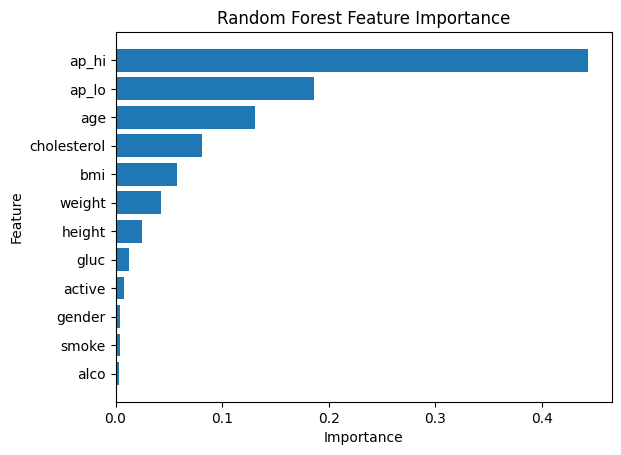

In [29]:
plt.figure()

plt.barh(importance_df["Feature"], importance_df["Importance"])

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

<Figure size 640x480 with 0 Axes>

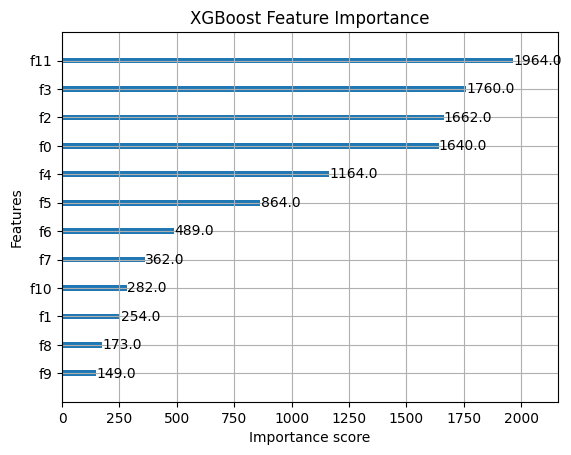

In [30]:
from xgboost import plot_importance

plt.figure()

plot_importance(xgb_model)

plt.title("XGBoost Feature Importance")

plt.show()